# Chess Evaluations

References:
- Dataset: https://www.kaggle.com/datasets/ronakbadhe/chess-evaluations/data
- Python-chess: https://www.kaggle.com/code/wlifferth/part-1-understanding-python-chess-and-fen
- Chess FEN: https://en.wikipedia.org/wiki/Forsyth%E2%80%93Edwards_Notation

# Data Exploration

In [3]:
import pandas as pd
import numpy as np
import chess
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.base import BaseEstimator
from IPython.display import display, Math

In [4]:
DATASET_FILE = "data/chessData.csv"
DATASET_SIZE = 10_000
FEN = "FEN"
EVAL = "Evaluation"
RANDOM_STATE = 99

In [5]:
raw_df = pd.read_csv(DATASET_FILE, nrows=5000)
print(raw_df.columns)

Index(['FEN', 'Evaluation'], dtype='object')


Our dataset is made of roughly 13 millions different games. However, to test our model we will be dealing with extremely smaller samples, to save on memory and time. We observe that downloading the dataset into memory takes about 50 seconds the first time. Therefore, to estimate which evaluations benefit Black and which benefit White, we use a much smaller sample, as the full dataset contains approximately 13 million games. For this reason, we will work with a smaller sample for data exploration.

In [ ]:
free(raw_df)

NameError: name 'free' is not defined

In [6]:
dataframe = pd.read_csv(DATASET_FILE, nrows=1000000)

In [7]:
print("First rows:")
print(dataframe.head())

print(f"\nColumns: {dataframe.columns}")

dataframe[EVAL] = pd.to_numeric(dataframe[EVAL], errors='coerce')

pos = (dataframe[EVAL] > 0).sum()
neg = (dataframe[EVAL] < 0).sum()
zero = (dataframe[EVAL] == 0).sum()

all = dataframe[EVAL].notna().sum()  # not NAN

percent_pos = (pos / all) * 100
percent_neg = (neg / all) * 100
percert_zero = (zero / all) * 100

print(f"Positives: {pos} ({percent_pos:.2f}%)")
print(f"Negatives: {neg} ({percent_neg:.2f}%)")
print(f"Zeros: {zero} ({percert_zero:.2f}%)")


First rows:
                                                 FEN Evaluation
0  rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...        -10
1  rnbqkbnr/pppp1ppp/4p3/8/4P3/8/PPPP1PPP/RNBQKBN...        +56
2  rnbqkbnr/pppp1ppp/4p3/8/3PP3/8/PPP2PPP/RNBQKBN...         -9
3  rnbqkbnr/ppp2ppp/4p3/3p4/3PP3/8/PPP2PPP/RNBQKB...        +52
4  rnbqkbnr/ppp2ppp/4p3/3p4/3PP3/8/PPPN1PPP/R1BQK...        -26

Columns: Index(['FEN', 'Evaluation'], dtype='object')
Positives: 536534 (54.16%)
Negatives: 346061 (34.93%)
Zeros: 108133 (10.91%)


In [7]:
EXAMPLE_GAME_ID = 50
EXAMPLE_FEN = dataframe["FEN"][EXAMPLE_GAME_ID]
EXAMPLE_FEN_FIELDS = EXAMPLE_FEN.split(" ")

labels = ["A","B","C","D","E","F"]

parts = [
    rf"\underbrace{{ \text{{{field}}} }}_{{ {label} }}"
    for field, label in zip(EXAMPLE_FEN_FIELDS, labels)
]

board = chess.Board(dataframe["FEN"][EXAMPLE_GAME_ID])

## FEN

Forsyth–Edwards Notation (FEN) is a standard notation for describing a particular board position of a chess game. The purpose of FEN is to provide all the necessary information to restart a game from a particular position.

A FEN record contains six fields, each separated by a space, e.g.:

<IPython.core.display.Math object>

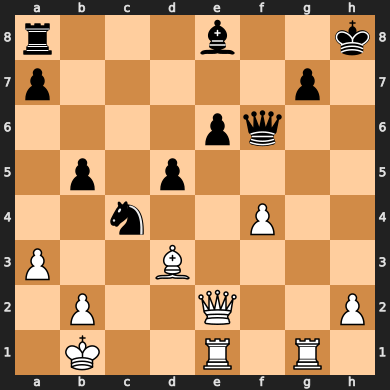

In [8]:
display(Math(r" \quad ".join(parts)))
display(board)

The fields are as follows:

- $A$: Piece placement
    - pawn = "P", knight = "N", bishop = "B", rook = "R", queen = "Q" and king = "K"
    - uppercase letters are white pieces, lowercase black pieces
    - digits from 1 to 8 indicate consecutive empty squares
    - for each rank (rank=row, 8 of them separated by "/") there are all the pieces described, starting from the a file (file=colum)
    - e.g.
- $B$: Active color: "w" for white to move, "b" for black
- $C$: [Castling](https://chess.fandom.com/wiki/Castling) availability
    - indicates which side (if any) can still castle (the right to castle can be lost once the king moves, something that you can't deduce from one single board position)
    - "K" for kingside castle, "Q" for queenside (lower case for black pieces), and "-" for none
- $D$: [En passant](https://chess.fandom.com/wiki/En_passant) target square
    - squares (in algebraic notation) over which a pawn has just passed while moving two squares
    - "-" for no squares
- $E$: Halfmove clock: number of halfmoves since the last capture or pawn advance (used for the [fifty-move rule](https://chess.fandom.com/wiki/Fifty_move_rule))
- $F$: Fullmove number: number of the moves since the beginning of the game

this whole project is about feature engineering, so extracting features from the FEN, blablabla...

# Cleaning

The evaluation feature is a string that contains the [centipawn evaluation](https://chess.fandom.com/wiki/Centipawn), and in the case of forced checkmate in less than 22 moves (the engine's depth), a hashtag is included at the beginning together with the number of moves. This is an edge-case, which is of no interest for our current goals. Moreover, these cases represent less than 1% of the dataset, which is already big enough, so we can just eliminate these rows.

Source: https://www.kaggle.com/datasets/ronakbadhe/chess-evaluations/discussion/497472#2775858

In [9]:
dataframe[dataframe["Evaluation"].str[0] == "#"]

,FEN,Evaluation
59,7k/p1r2b2/4pq2/1p1p1nR1/5P2/P2B4/1P2Q2P/1K4R1 ...,#+6
60,7k/p1r2b2/4pq2/1p1p1BR1/5P2/P7/1P2Q2P/1K4R1 b ...,#+6
61,7k/p1r2b2/5q2/1p1p1pR1/5P2/P7/1P2Q2P/1K4R1 w -...,#+4
62,7k/p1r2b2/5q2/1p1p1p1R/5P2/P7/1P2Q2P/1K4R1 b -...,#+3
1440,7Q/8/4k3/p1p2p2/P7/1Pp1q1K1/6P1/8 w - - 3 64,#-19
1989,3r3k/p4Q2/3bp2p/2ppqp2/8/P1P3RP/1P3PP1/3R2K1 w...,#+5
1990,3r3k/p4Q2/3bp1Rp/2ppqp2/8/P1P4P/1P3PP1/3R2K1 b...,#+4
2561,6k1/p4p2/2b3pQ/5q2/2p5/P1P3R1/4r1PP/3Rn1K1 b -...,#-2
2562,6k1/p4p2/2b3pQ/8/2p5/P1P3R1/4rqPP/3Rn1K1 w - -...,#-1
3311,3q3r/5R2/7k/1b1pPp1p/p2P4/Q7/6PP/1r2BRK1 w - -...,#+8


In [10]:
dataframe = dataframe[~dataframe[EVAL].astype(str).str.contains("#")].copy()
dataframe[EVAL] = pd.to_numeric(dataframe[EVAL], errors="coerce").astype(int)

In [11]:
display(dataframe.dtypes[EVAL])
display(sum(dataframe[EVAL].isna()))

dtype('int64')

0

We also see the evaluation has a vast range of values, but most of them are accumulated around zero.

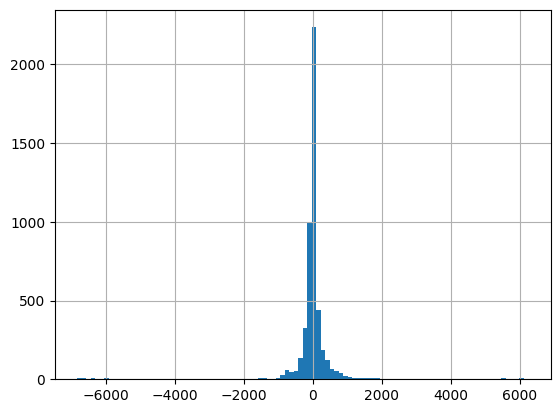

In [12]:
dataframe[EVAL].hist(bins=100)
plt.show()

So we want to either clip them to a maximum (say 1000) or consider them outliers and remove them from the training dataset. For now, we will consider the dataset clipped at 1000.

In [13]:
dataframe[EVAL] = np.clip(dataframe[EVAL], -1000, 1000)

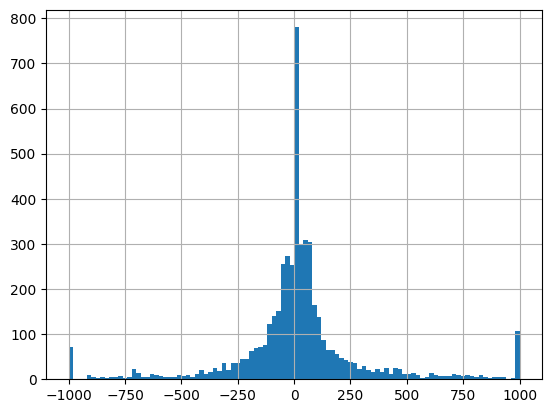

In [14]:
dataframe[EVAL].hist(bins=100)
plt.show()

# Evaluation Cleaner

In [15]:
class EvaluationCleaner:
    name = "Evaluation Cleaner"
    features = []

    @staticmethod
    def clean(df: pd.DataFrame, mode: str = "remove", threshold: int = 1000) -> pd.DataFrame:
        df = df[~df[EVAL].astype(str).str.contains("#")]
        df.loc[:, EVAL] = pd.to_numeric(df[EVAL], errors="coerce").astype(int)
        if mode == "clip":
            df.loc[:, EVAL] = np.clip(df[EVAL], -threshold, threshold)
        elif mode == "remove":
            df = df[df[EVAL].abs() <= threshold]
        else:
            raise ValueError("mode must be 'clip' or 'remove'")
        return df

# Data Manager

In [16]:
class DataManager:
    def __init__(self, filepath: str, read_size: int = 5_000_000, sample_size: int = 100_000, test_size: float = 0.2, random_state: int = 99, features: list = None, cleaner = EvaluationCleaner, transformers: list = None):
        self.filepath = filepath
        self.read_size = read_size
        self.sample_size = sample_size
        self.test_size = test_size
        self.random_state = random_state
        self.features = features or set()
        self.cleaner = cleaner
        self.transformers = transformers or [] # each element is a class with a 'transform' method and; a 'name','features' and 'methods' attributes corresponding to the transformer identification.

        assert sample_size <= read_size, f"Sample size ({sample_size}) must be smaller than read size ({read_size})."

        self.df_all = pd.read_csv(filepath, nrows=read_size)
        self.df = None

        self.X = None
        self.y = None

        self.X_train = None
        self.X_test  = None
        self.y_train = None
        self.y_test  = None

        self.df_all = self.cleaner.clean(self.df_all)
        self.sample()

        if len(self.transformers) > 0:
            self.apply_transformers()
            self.train_test_split()

    def sample(self, sample_size: int = None):
        """Sample random rows."""
        if sample_size is not None:
            self.sample_size = sample_size
        self.df = self.df_all.sample(n=self.sample_size, random_state=self.random_state).reset_index(drop=True)
        self.X = self.df[[FEN]]
        self.y = self.df[EVAL]
        return self.df

    def apply_transformers(self, transformers: list = None):  
        """Apply transformers to dataframe."""
        if transformers is not None:
            self.transformers = transformers 
        elif self.transformers is None:
            return self.X
        with tqdm(self.transformers, desc="Applying transformations", leave=False) as pbar:
            for transformer in pbar:
                if not transformer.features.issubset(self.features): 
                    pbar.set_postfix({"transformer": transformer.name})
                    self.X = transformer.transform(self.X)
                    self.features.update(transformer.features)
        self.train_test_split()
        return self.X

    def train_test_split(self, features: list = None, test_size: float = None, random_state: int = None):
        """First sample then split."""
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X[list(features or self.features)],
            self.y,
            test_size=test_size or self.test_size,
            random_state=random_state or self.random_state
        )

        return self.X_train, self.X_test, self.y_train, self.y_test

The most important function from this class is apply_transformers, which develops the application of each transformer in our dataset, and updating only the features set (each transformer has to be defined before applying it). As we are just interested in the features, there is no need to accumulate the transformers, so we replace the last transformers for the new ones in every iteration. We make sure we only apply the transformer if its features are not already in the dataset.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   FEN         10000 non-null  object
 1   Evaluation  10000 non-null  object
dtypes: object(2)
memory usage: 1.4 MB


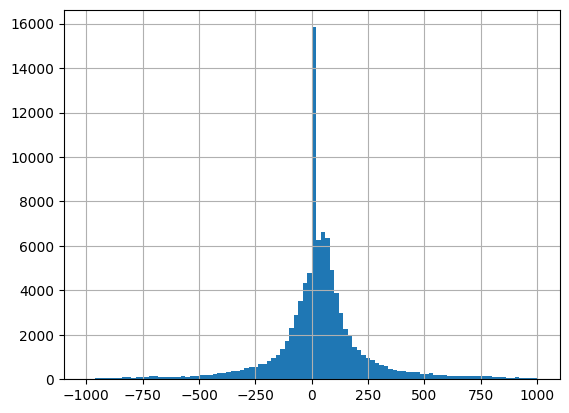

In [17]:
dm = DataManager(DATASET_FILE, sample_size=10_000, read_size=100_000, random_state=RANDOM_STATE)
DATAFRAME = dm.df
DATAFRAME.info(memory_usage="deep")
dm.df_all[EVAL].hist(bins=100)
plt.show()

# Chess Manager

In [18]:
class ChessManager:
    def __init__(self, dm: DataManager):
        self.dm = dm

    def show_board(self, idx: int):
        fen = self.dm.df.loc[idx, FEN]
        display(chess.Board(fen))

    def show_features(self, idx: int):
        display(self.dm.df.loc[idx])

    def show(self, idx: int):
        self.show_features(idx)
        self.show_board(idx)

FEN           r5k1/1p4p1/1n2p3/n2pP3/p2P4/P1N1P1r1/1P2b2N/4R...
Evaluation                                                   -6
Name: 100, dtype: object

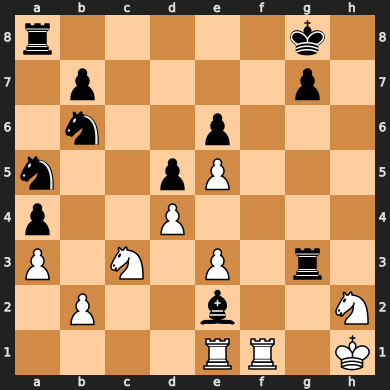

In [19]:
cm = ChessManager(dm)
cm.show(100)

From now on, we will be creating several classes to implement the feature engineering, with the object-oriented programming techniques, such as @staticmethod, wich is interesting if we want to be adding new functions in the future. The idea is to create a class with a "tranform" function whcih with the help of other functions also defined inside the class, it is feasible to update the Class' features and then apply the "apply_transformers" to the data model. Then, we will be analysing how does the model behave with upcoming metrics section, so that we can see the (expected) improvment provided by our feature engineering.

# Number of Pieces

Here we have the first class, which we believe provides a large part of the game information needed to predict the evidence. These are the foundations for building more complex features.

In [20]:
class PieceInfo:
    name = "Piece Information"
    features = set()
    methods = list()

    @staticmethod
    def extract_total_piece_count(dataframe: pd.DataFrame) -> pd.DataFrame:
        out = dataframe.copy()

        def count(fen):
            temp_board = chess.Board(fen)
            white = sum(1 for p in temp_board.piece_map().values() if p.color)
            black = sum(1 for p in temp_board.piece_map().values() if not p.color)
            return white, black

        w, b = zip(*out[FEN].apply(count))
        out["White_Pieces"] = w
        out["Black_Pieces"] = b

        return out

    @staticmethod
    def transform(dataframe: pd.DataFrame) -> pd.DataFrame:
        out = dataframe.copy()
        out.drop(columns=PieceInfo.features, inplace=True, errors="ignore")
        for method in PieceInfo.methods:
            out = method(out)
        return out

PieceInfo.features.update(("White_Pieces", "Black_Pieces"))
PieceInfo.methods.append(PieceInfo.extract_total_piece_count)

In [21]:
dm.apply_transformers([PieceInfo])

Applying transformations:   0%|          | 0/1 [00:00<?, ?it/s, transformer=Piece Information]

,FEN,White_Pieces,Black_Pieces
0,6r1/2R4p/2bp1p1K/4pP2/1pPkP1P1/1P1P1B2/8/8 b -...,9,8
1,1rbqr1k1/3n1pbp/pp1p2p1/2pP4/P3P1nN/1PN3PP/1BQ...,15,15
2,8/5pk1/7p/r5PP/5PK1/7R/8/8 b - - 2 105,5,4
3,r3r1k1/1b3pbp/1p2p1p1/p2pP3/2qP1P1B/P1N2R2/1P4...,13,13
4,8/5k2/4pp2/np6/4KPP1/1P6/8/2N5 b - - 3 34,5,5
...,...,...,...
9995,2kr4/4bp2/2pqb1p1/p2pN3/1p1P4/P2BP3/1PP3P1/2K1...,11,11
9996,3r1rk1/pbqnbppp/1p2pn2/2pp4/2P5/1P1PPNP1/PB1NQ...,16,16
9997,r2qbbk1/p5pn/1pp1r2p/2PpN3/1P1P2P1/2NQ1R1P/P4P...,14,13
9998,3r1rk1/pp3pb1/2n1b1pp/2pN4/4P2q/2NB4/PP3PPP/2R...,13,13


# Model Manager

This class trains a model using the data manager and provides prediction methods, including generating a prediction from a given FEN string by preprocessing it to match the model’s input format. 

In [22]:
class ModelManager:
    def __init__(self, model: BaseEstimator, dm: DataManager):
        self.model = model
        self.dm = dm
        self.y_pred = None

        self.fit()

    def fit(self):
        self.model.fit(self.dm.X_train, self.dm.y_train)

    def predict(self):
        self.y_pred = self.model.predict(self.dm.X_test)
        return self.y_pred

    def predict_fen(self, fen: str):
        df_fen = pd.DataFrame({FEN: [fen]})
        if self.dm.transformers:
            for transformer in self.dm.transformers:
                df_fen = transformer.transform(df_fen)

        # Prepare X_new with the same columns as X_train
        X_new = df_fen.drop(FEN, axis=1)
        for col in self.dm.X_train.columns:
            if col not in X_new.columns:
                X_new[col] = 0  # Add the missing column with default value 0
        X_new = X_new[self.dm.X_train.columns]  # rearrange columns to match

        return self.model.predict(X_new)


In [23]:
mm = ModelManager(GradientBoostingRegressor(), dm)
mm.predict()
mm.predict_fen(fen=cm.dm.df.loc[EXAMPLE_GAME_ID, FEN])

array([41.81488592])

# Metrics Manager

And for an already selected model, we will need a MetricsManager, which will compute different evaluation metrics and generate plots to analyze the model’s performance.

In [24]:
class MetricsManager:
    def __init__(self, mm: ModelManager):
        self.mm = mm

    @property
    def y_true(self):
        return self.mm.dm.y_test

    @property
    def y_pred(self):
        return self.mm.y_pred

    def sign_accuracy(self):
        true_sign = np.sign(self.y_true)
        pred_sign = np.sign(self.y_pred)
        true_sign[true_sign == 0] = 0
        pred_sign[pred_sign == 0] = 0
        return np.mean(true_sign == pred_sign)

    def sign_recall(self, player: str = "white"):
        true_sign = np.sign(self.y_true)
        pred_sign = np.sign(self.y_pred)

        if player == "white":
            mask = true_sign > 0
        elif player == "black":
            mask = true_sign < 0
        elif player == "draw":
            mask = true_sign == 0
        else:
            raise ValueError("player must be 'white' or 'black'")

        if mask.sum() == 0:
            return np.nan

        return np.sum(pred_sign[mask] == true_sign[mask]) / np.sum(mask)

    def centipawn_accuracy(self, tol=200):
        return np.mean(np.abs(self.y_true - self.y_pred) <= tol)

    def plot_scatter(self):
        plt.figure(figsize=(10, 8))
        plt.scatter(self.y_true, self.y_pred, alpha=0.5)
        plt.xlabel("True Eval")
        plt.ylabel("Predicted Eval")
        plt.show()

    def report(self, tol=200):
        print("MSE:", mean_squared_error(self.y_true, self.y_pred))
        print("Sign accuracy:", self.sign_accuracy())
        print("White winning recall:", self.sign_recall("white"))
        print("Black winning recall:", self.sign_recall("black"))
        print("Draw recall:", self.sign_recall("draw"))
        print(f"Centipawn ±{tol} accuracy:", self.centipawn_accuracy(tol))

    def plot_eval(self, f1, f2):
        w_vals = np.linspace(self.mm.dm.df[f1].min(), self.mm.dm.df[f1].max(), 100)
        b_vals = np.linspace(self.mm.dm.df[f2].min(), self.mm.dm.df[f2].max(), 100)
        W, B = np.meshgrid(w_vals, b_vals)

        grid_df = pd.DataFrame({f1: W.ravel(), f2: B.ravel()})
        Z = self.mm.model.predict(grid_df).reshape(W.shape)

        plt.figure(figsize=(8,10))
        contour = plt.contourf(W, B, Z, levels=50, cmap="viridis")
        plt.colorbar(contour, label="Predicted Evaluation (centipawns)")

        zero_line = plt.contour(W, B, Z, levels=[0], colors="white")
        plt.clabel(zero_line, fmt="0", fontsize=10)

        plt.xlabel(f1)
        plt.ylabel(f2)
        plt.title("Predicted Evaluation")

        plt.show()

    def plot_tol_acc(self, max_tol=1000):
        tols = np.linspace(0, max_tol, 1000)
        accs = [self.centipawn_accuracy(tol) for tol in tols]

        auc = np.trapezoid(accs, tols) / max_tol

        plt.figure(figsize=(10, 8))
        plt.plot(tols, accs)
        plt.title(f"Tolerance-Accuracy Curve (AUC = {auc:.2f})")
        plt.xlabel("Centipawn Tolerance")
        plt.ylabel("Accuracy")
        plt.show()

MSE: 40582.785392762635
Sign accuracy: 0.5925
White winning recall: 0.9415467625899281
Black winning recall: 0.20783132530120482
Draw recall: 0.0
Centipawn ±200 accuracy: 0.8045


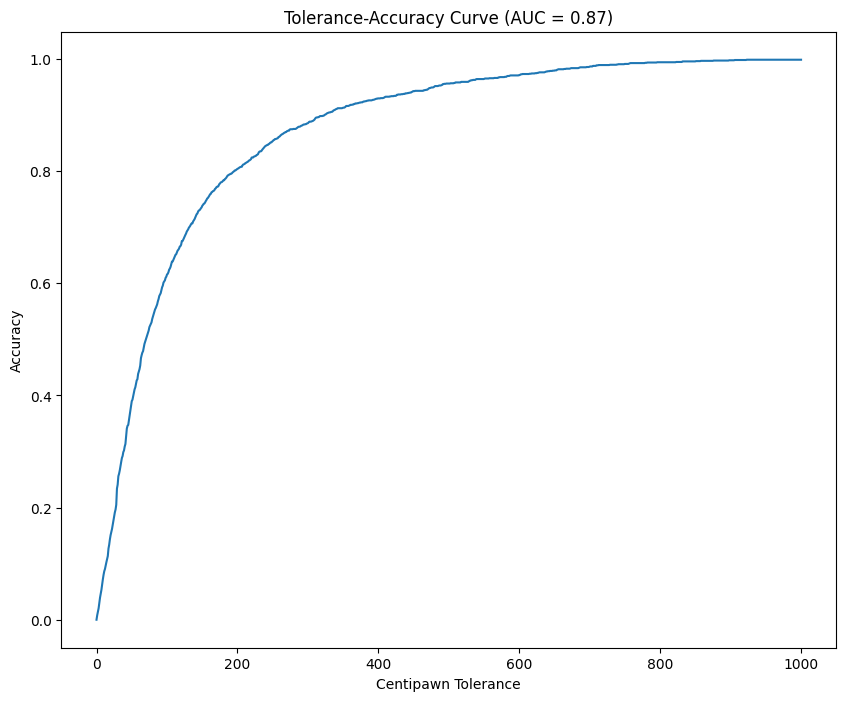

In [25]:
metm = MetricsManager(mm)
metm.report()
metm.plot_tol_acc()


# Basic Features

The most natural indicator that one would consider to predict the advantage of the players is the piece count: how many pieces does each player have. So, we code the first transformer to extract the piece count from the FEN.

Right away, we test our simple model with only these basic features. We will be considering a simple Random Forest and Linear Regressor.

Since the dataset is fairly balanced (54%-37), we will consider the plain sign accuracy of our prediction. For now, we are just checking the evaluation's sign because the RMSE is not yet a good indicator for model fitness.

## Piece values

Source: https://chess.fandom.com/wiki/Value

In [26]:
PIECE_VALUATIONS = {
    "standard": {
        chess.PAWN: 100,
        chess.KNIGHT: 300,
        chess.BISHOP: 300,
        chess.ROOK: 500,
        chess.QUEEN: 900,
        chess.KING: 0
    },
    "Jacob Sarratt's": {
        chess.PAWN: 100,
        chess.KNIGHT: 462,
        chess.BISHOP: 487,
        chess.ROOK: 750,
        chess.QUEEN: 1187,
        chess.KING: 0
    }
}

In [27]:
def extract_piece_values(dataframe: pd.DataFrame, valuation: str = "standard") -> pd.DataFrame:
    out = dataframe.copy()

    def piece_score(fen):
        temp_board = chess.Board(fen)
        white_score = 0
        black_score = 0

        for p in temp_board.piece_map().values():
            value = PIECE_VALUATIONS[valuation][p.piece_type]
            if p.color:
                white_score += value
            else:
                black_score += value

        return white_score, black_score

    w_val, b_val = zip(*dataframe[FEN].apply(piece_score))

    out["White_Piece_Value"] = w_val
    out["Black_Piece_Value"] = b_val

    return out

PieceInfo.features.update(("White_Piece_Value", "Black_Piece_Value"))
PieceInfo.extract_piece_values = staticmethod(extract_piece_values) # in pyhton, it is possible to add static methods to a class after its definition.
PieceInfo.methods.append(PieceInfo.extract_piece_values)

In [28]:
dm.apply_transformers([PieceInfo])

,FEN,White_Pieces,Black_Pieces,White_Piece_Value,Black_Piece_Value
0,6r1/2R4p/2bp1p1K/4pP2/1pPkP1P1/1P1P1B2/8/8 b -...,9,8,1400,1300
1,1rbqr1k1/3n1pbp/pp1p2p1/2pP4/P3P1nN/1PN3PP/1BQ...,15,15,3800,3800
2,8/5pk1/7p/r5PP/5PK1/7R/8/8 b - - 2 105,5,4,800,700
3,r3r1k1/1b3pbp/1p2p1p1/p2pP3/2qP1P1B/P1N2R2/1P4...,13,13,3200,3200
4,8/5k2/4pp2/np6/4KPP1/1P6/8/2N5 b - - 3 34,5,5,600,600
...,...,...,...,...,...
9995,2kr4/4bp2/2pqb1p1/p2pN3/1p1P4/P2BP3/1PP3P1/2K1...,11,11,2600,2600
9996,3r1rk1/pbqnbppp/1p2pn2/2pp4/2P5/1P1PPNP1/PB1NQ...,16,16,3900,3900
9997,r2qbbk1/p5pn/1pp1r2p/2PpN3/1P1P2P1/2NQ1R1P/P4P...,14,13,3500,3400
9998,3r1rk1/pp3pb1/2n1b1pp/2pN4/4P2q/2NB4/PP3PPP/2R...,13,13,3400,3400


MSE: 36890.32568665002
Sign accuracy: 0.603
White winning recall: 0.935251798561151
Black winning recall: 0.25
Draw recall: 0.0
Centipawn ±200 accuracy: 0.8155


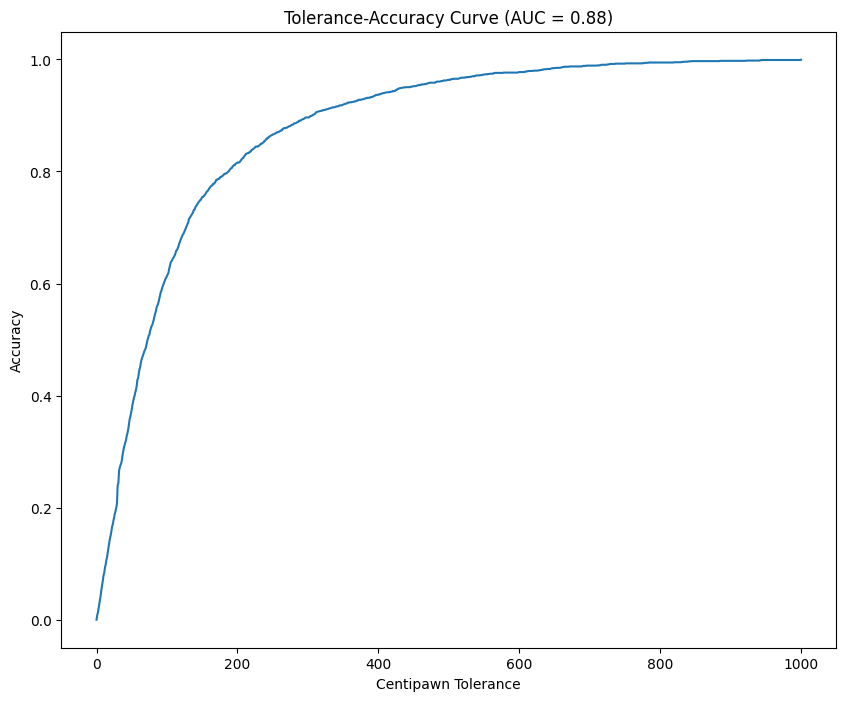

In [29]:
mm.fit()
mm.predict()
metm.report()
metm.plot_tol_acc()

## Number of Individual Piece Types

In [30]:
def extract_piece_count(dataframe: pd.DataFrame) -> pd.DataFrame:
    out = dataframe.copy()

    def count_types(fen):
        board = chess.Board(fen)
        piece_map = board.piece_map()

        # result dict { "White_PAWN": n, "Black_PAWN": n, ... }
        counts = {}

        for ptype in (
            chess.PAWN,
            chess.KNIGHT,
            chess.BISHOP,
            chess.ROOK,
            chess.QUEEN
        ):
            w = sum(1 for p in piece_map.values() if p.piece_type == ptype and p.color)
            b = sum(1 for p in piece_map.values() if p.piece_type == ptype and not p.color)
            counts[f"White_{chess.piece_name(ptype).capitalize()}"] = w
            counts[f"Black_{chess.piece_name(ptype).capitalize()}"] = b

        return counts

    feature_dicts = dataframe[FEN].apply(count_types)
    feature_df = pd.DataFrame(feature_dicts.tolist(), index=dataframe.index)

    out = pd.concat([out, feature_df], axis=1)
    return out

PieceInfo.features.update((
    "White_Pawn", "Black_Pawn",
    "White_Knight", "Black_Knight",
    "White_Bishop", "Black_Bishop",
    "White_Rook", "Black_Rook",
    "White_Queen", "Black_Queen"
))
PieceInfo.extract_piece_count = staticmethod(extract_piece_count)
PieceInfo.methods.append(PieceInfo.extract_piece_count)

In [31]:
dm.apply_transformers([PieceInfo])

,FEN,White_Pieces,Black_Pieces,White_Piece_Value,Black_Piece_Value,White_Pawn,Black_Pawn,White_Knight,Black_Knight,White_Bishop,Black_Bishop,White_Rook,Black_Rook,White_Queen,Black_Queen
0,6r1/2R4p/2bp1p1K/4pP2/1pPkP1P1/1P1P1B2/8/8 b -...,9,8,1400,1300,6,5,0,0,1,1,1,1,0,0
1,1rbqr1k1/3n1pbp/pp1p2p1/2pP4/P3P1nN/1PN3PP/1BQ...,15,15,3800,3800,7,7,2,2,2,2,2,2,1,1
2,8/5pk1/7p/r5PP/5PK1/7R/8/8 b - - 2 105,5,4,800,700,3,2,0,0,0,0,1,1,0,0
3,r3r1k1/1b3pbp/1p2p1p1/p2pP3/2qP1P1B/P1N2R2/1P4...,13,13,3200,3200,7,7,1,0,1,2,2,2,1,1
4,8/5k2/4pp2/np6/4KPP1/1P6/8/2N5 b - - 3 34,5,5,600,600,3,3,1,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2kr4/4bp2/2pqb1p1/p2pN3/1p1P4/P2BP3/1PP3P1/2K1...,11,11,2600,2600,6,6,1,0,1,2,1,1,1,1
9996,3r1rk1/pbqnbppp/1p2pn2/2pp4/2P5/1P1PPNP1/PB1NQ...,16,16,3900,3900,8,8,2,2,2,2,2,2,1,1
9997,r2qbbk1/p5pn/1pp1r2p/2PpN3/1P1P2P1/2NQ1R1P/P4P...,14,13,3500,3400,7,6,2,1,1,2,2,2,1,1
9998,3r1rk1/pp3pb1/2n1b1pp/2pN4/4P2q/2NB4/PP3PPP/2R...,13,13,3400,3400,6,6,2,1,1,2,2,2,1,1


MSE: 36430.85904128267
Sign accuracy: 0.6075
White winning recall: 0.927158273381295
Black winning recall: 0.27710843373493976
Draw recall: 0.0
Centipawn ±200 accuracy: 0.824


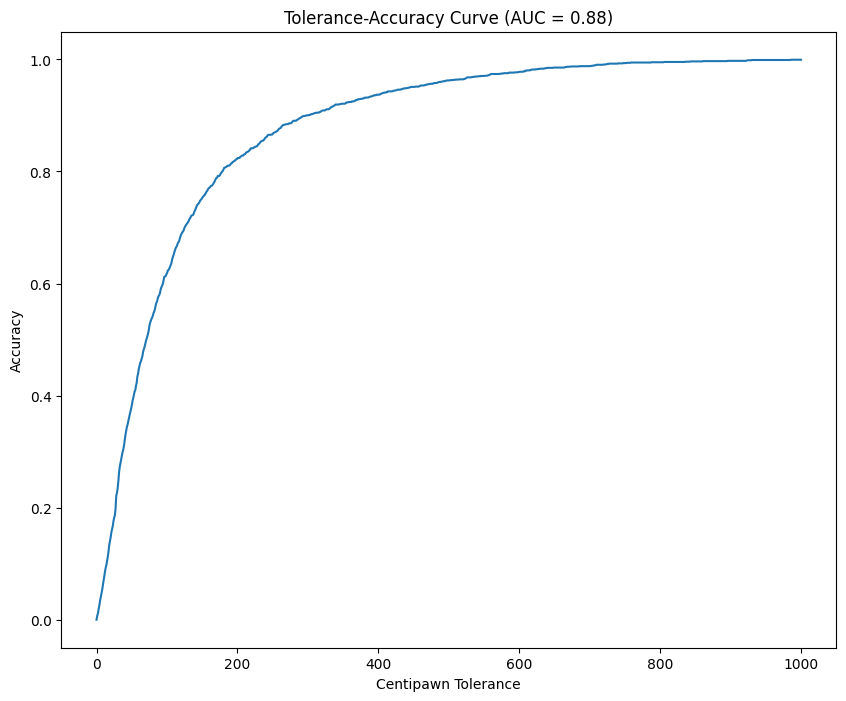

In [32]:
mm.fit()
mm.predict()
metm.report()
metm.plot_tol_acc()

In [33]:
importances = mm.model.feature_importances_
names = mm.dm.X.columns

ranked = sorted(zip(names, importances), key=lambda x: x[1], reverse=True)

for name, imp in ranked:
    print(name, imp)

White_Pieces 0.3053343180876515
Black_Knight 0.25329964609376676
White_Queen 0.0980129070211401
Black_Pieces 0.08390134765034503
White_Bishop 0.07337991033674175
Black_Pawn 0.06330151959876168
White_Piece_Value 0.029211199532501755
FEN 0.018884999115005484
White_Rook 0.01869096997199002
White_Knight 0.016926224368141663
White_Pawn 0.014554950508994854
Black_Bishop 0.013217516284902696
Black_Rook 0.007510681033832359
Black_Piece_Value 0.003773810396224391


### Extracting Piece's Valuations

In [34]:
mm_lr = ModelManager(LinearRegression(), dm)
mm_lr.predict()
metm.mm = mm_lr
metm.report()

MSE: 41114.19973021874
Sign accuracy: 0.5935
White winning recall: 0.8839928057553957
Black winning recall: 0.3072289156626506
Draw recall: 0.0
Centipawn ±200 accuracy: 0.804


In [35]:
coefs = pd.Series(mm_lr.model.coef_, index=dm.X_train.columns)
intercept = mm_lr.model.intercept_
piece_types = ["Pawn","Knight","Bishop","Rook","Queen"]

avg_abs = {}
for p in piece_types:
    cols = [c for c in coefs.index if p in c]
    vals = coefs[cols].abs()
    avg_abs[p] = vals.mean()

avg_abs = pd.Series(avg_abs)

pawn_val = avg_abs["Pawn"]
queen_val = avg_abs["Queen"]

scale = (900 - 100) / (queen_val - pawn_val)
shift = 100 - pawn_val * scale

normalized = avg_abs * scale + shift
normalized

Pawn       100.000000
Knight     671.245725
Bishop    1045.506648
Rook       908.156476
Queen      900.000000
dtype: float64

In this section, we have seen that our model has been gaining better results in the metrics. Even though this is a really premature conclusion, as there is not a Cross-Validation method, we started with a 0.8045 Centipawn ±200 accuracy and a 0.87 AUC and we arrived up to 0.824 Centipawn ±200 accuracy and a 0.88 AUC.

## Pawn Structure

In [36]:
class PawnStructure:
    name = "Pawn Structure"
    features = {"Isolated_Pawns_White", "Isolated_Pawns_Black", "Doubled_Pawns_White", "Doubled_Pawns_Black", "Passed_Pawns_White", "Passed_Pawns_Black"}

    @staticmethod
    def fen_to_file_counts(fen):
            temp_board = chess.Board(fen)
            white_counts = [0]*8
            black_counts = [0]*8
            for square in chess.SQUARES:
                piece = temp_board.piece_at(square)
                if piece is None:
                    continue
                file_idx = chess.square_file(square)
                if piece.piece_type == chess.PAWN:
                    if piece.color == chess.WHITE:
                        white_counts[file_idx] += 1
                    else:
                        black_counts[file_idx] += 1
            return white_counts, black_counts

    @staticmethod
    def isolated(pawn_counts):
            count = 0
            for i, c in enumerate(pawn_counts):
                if c == 0:
                    continue
                left = pawn_counts[i-1] if i > 0 else 0
                right = pawn_counts[i+1] if i < 7 else 0
                if left == 0 and right == 0:
                    count += c
            return count

    @staticmethod
    def doubled(pawn_counts):
        return sum(c-1 for c in pawn_counts if c > 1)

    @staticmethod
    def passed(own_counts, opp_counts):
            count = 0
            for i, c in enumerate(own_counts):
                if c == 0:
                    continue
                front_files = [i]
                if i > 0:
                    front_files.append(i-1)
                if i < 7:
                    front_files.append(i+1)
                blocked = any(opp_counts[f] > 0 for f in front_files)
                if not blocked:
                    count += c
            return count

    @classmethod
    def transform(cls, df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()

        counts = df["FEN"].apply(lambda fen: cls.fen_to_file_counts(fen))
        white_counts = counts.apply(lambda x: x[0])
        black_counts = counts.apply(lambda x: x[1])

        out["Isolated_Pawns_White"] = white_counts.apply(cls.isolated)
        out["Isolated_Pawns_Black"] = black_counts.apply(cls.isolated)
        out["Doubled_Pawns_White"] = white_counts.apply(cls.doubled)
        out["Doubled_Pawns_Black"] = black_counts.apply(cls.doubled)
        out["Passed_Pawns_White"] = [cls.passed(w, b) for w, b in zip(white_counts, black_counts)]
        out["Passed_Pawns_Black"] = [cls.passed(b, w) for w, b in zip(white_counts, black_counts)]

        return out

In [37]:
dm.apply_transformers([PawnStructure])

,FEN,White_Pieces,Black_Pieces,White_Piece_Value,Black_Piece_Value,White_Pawn,Black_Pawn,White_Knight,Black_Knight,White_Bishop,...,White_Rook,Black_Rook,White_Queen,Black_Queen,Isolated_Pawns_White,Isolated_Pawns_Black,Doubled_Pawns_White,Doubled_Pawns_Black,Passed_Pawns_White,Passed_Pawns_Black
0,6r1/2R4p/2bp1p1K/4pP2/1pPkP1P1/1P1P1B2/8/8 b -...,9,8,1400,1300,6,5,0,0,1,...,1,1,0,0,0,2,0,0,0,0
1,1rbqr1k1/3n1pbp/pp1p2p1/2pP4/P3P1nN/1PN3PP/1BQ...,15,15,3800,3800,7,7,2,2,2,...,2,2,1,1,0,0,0,0,0,0
2,8/5pk1/7p/r5PP/5PK1/7R/8/8 b - - 2 105,5,4,800,700,3,2,0,0,0,...,1,1,0,0,0,2,0,0,0,0
3,r3r1k1/1b3pbp/1p2p1p1/p2pP3/2qP1P1B/P1N2R2/1P4...,13,13,3200,3200,7,7,1,0,1,...,2,2,1,1,0,0,0,0,0,0
4,8/5k2/4pp2/np6/4KPP1/1P6/8/2N5 b - - 3 34,5,5,600,600,3,3,1,1,0,...,0,0,0,0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2kr4/4bp2/2pqb1p1/p2pN3/1p1P4/P2BP3/1PP3P1/2K1...,11,11,2600,2600,6,6,1,0,1,...,1,1,1,1,1,0,0,0,0,0
9996,3r1rk1/pbqnbppp/1p2pn2/2pp4/2P5/1P1PPNP1/PB1NQ...,16,16,3900,3900,8,8,2,2,2,...,2,2,1,1,0,0,0,0,0,0
9997,r2qbbk1/p5pn/1pp1r2p/2PpN3/1P1P2P1/2NQ1R1P/P4P...,14,13,3500,3400,7,6,2,1,1,...,2,2,1,1,0,0,0,0,0,0
9998,3r1rk1/pp3pb1/2n1b1pp/2pN4/4P2q/2NB4/PP3PPP/2R...,13,13,3400,3400,6,6,2,1,1,...,2,2,1,1,0,0,0,0,0,0


MSE: 41114.19973021874
Sign accuracy: 0.5935
White winning recall: 0.8839928057553957
Black winning recall: 0.3072289156626506
Draw recall: 0.0
Centipawn ±200 accuracy: 0.804


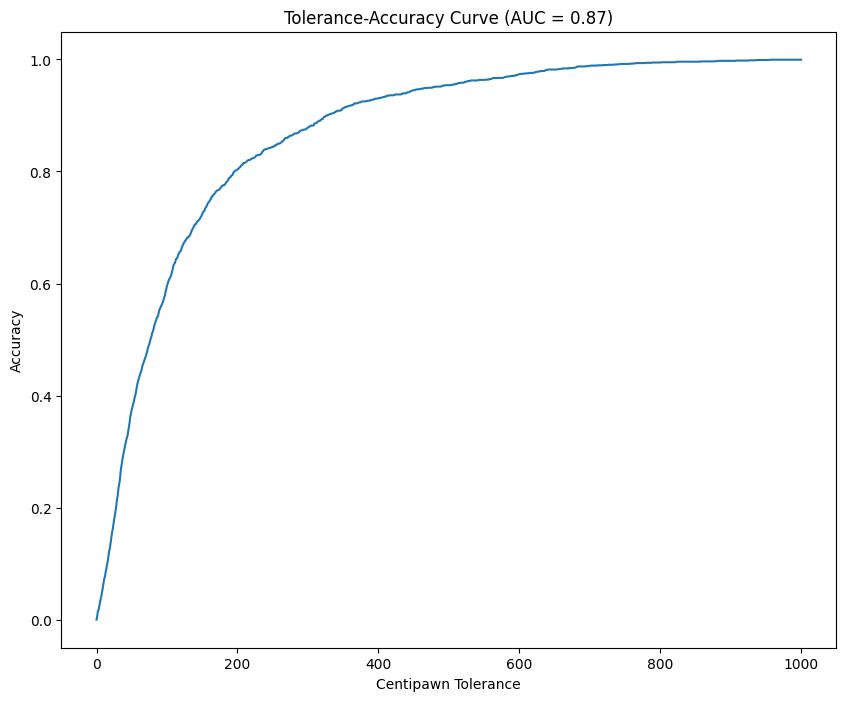

In [38]:
dm.train_test_split(list(PieceInfo.features | PawnStructure.features))
mm.fit()
mm.predict()
metm.report()
metm.plot_tol_acc()

Here we can see that the model metrics are dropping again, as they were with the model counting only the number of pieces. We attribute this to [COMPLETE!!!]

## King Safety

Pawns located near the king is the pillar for king's safety. We all know that _the more, the merrier_. Here we put in practice this well-known idiom (the more pawns you have near your king, the safer and better protected he is). This class extracts positional board-control features such as central control, open files, rook placement, piece alignment, protected advanced pawns, and total controlled squares to quantify strategic dominance.

In [39]:
class KingSafety:
    name = "King Safety"
    features = {
        "King_Castled_White",
        "King_Castled_Black",
        "King_Pawns_White",
        "King_Pawns_Black",
        "Open_Files",
        "King_Distance_to_Last_Rank_White",
        "King_Distance_to_Last_Rank_Black",
        "King_Castling_Rights_White",
        "King_Castling_Rights_Black",
        "King_Front_Pawns_White",
        "King_Front_Pawns_Black",
        "King_In_Check_White",
        "King_In_Check_Black",
        "King_Attacked_Neighbours_White",
        "King_Attacked_Neighbours_Black",
    }

    @staticmethod
    def king_castled(board, color):
        k = board.king(color)
        if color == chess.WHITE:
            return (k == chess.G1 and board.piece_at(chess.H1) == chess.Piece(chess.ROOK, chess.WHITE)) or \
                   (k == chess.C1 and board.piece_at(chess.A1) == chess.Piece(chess.ROOK, chess.WHITE))
        return (k == chess.G8 and board.piece_at(chess.H8) == chess.Piece(chess.ROOK, chess.BLACK)) or \
               (k == chess.C8 and board.piece_at(chess.A8) == chess.Piece(chess.ROOK, chess.BLACK))

    @staticmethod
    def king_pawns(board, color):
        sq = board.king(color)
        count = 0
        sf = chess.square_file(sq)
        sr = chess.square_rank(sq)
        for df in (-1, 0, 1):
            for dr in (-1, 0, 1):
                if df == 0 and dr == 0:
                    continue
                f = sf + df
                r = sr + dr
                if 0 <= f <= 7 and 0 <= r <= 7:
                    p = board.piece_at(chess.square(f, r))
                    if p and p.piece_type == chess.PAWN and p.color == color:
                        count += 1
        return count

    @staticmethod
    def open_files(board):
        count = 0
        for f in range(8):
            pawns_w = any(board.piece_at(chess.square(f, r)) == chess.Piece(chess.PAWN, chess.WHITE) for r in range(8))
            pawns_b = any(board.piece_at(chess.square(f, r)) == chess.Piece(chess.PAWN, chess.BLACK) for r in range(8))
            if not (pawns_w and pawns_b):
                count += 1
        return count

    @staticmethod
    def king_distance(board, color):
        sq = board.king(color)
        r = chess.square_rank(sq)
        return (7 - r) if color == chess.WHITE else r

    @staticmethod
    def king_castling_rights(board, color):
        return int(board.has_kingside_castling_rights(color) or board.has_queenside_castling_rights(color))

    @staticmethod
    def king_front_pawns(board, color):
        sq = board.king(color)
        f0 = chess.square_file(sq)
        r0 = chess.square_rank(sq)
        dr = 1 if color == chess.WHITE else -1
        count = 0
        for df in (-1, 0, 1):
            f = f0 + df
            r = r0 + dr
            if 0 <= f <= 7 and 0 <= r <= 7:
                p = board.piece_at(chess.square(f, r))
                if p and p.piece_type == chess.PAWN and p.color == color:
                    count += 1
        return count

    @staticmethod
    def king_in_check(board, color):
        return int(board.is_check() and board.turn == color)

    @staticmethod
    def king_attacked_neighbours(board, color):
        sq = board.king(color)
        sf = chess.square_file(sq)
        sr = chess.square_rank(sq)
        enemy = not color
        count = 0
        for df in (-1, 0, 1):
            for dr in (-1, 0, 1):
                if df == 0 and dr == 0:
                    continue
                f = sf + df
                r = sr + dr
                if 0 <= f <= 7 and 0 <= r <= 7:
                    sq2 = chess.square(f, r)
                    if board.is_attacked_by(enemy, sq2):
                        count += 1
        return count

    @classmethod
    def transform(cls, df: pd.DataFrame) -> pd.DataFrame:
        def compute(fen):
            board = chess.Board(fen)
            return {
                "King_Castled_White": cls.king_castled(board, chess.WHITE),
                "King_Castled_Black": cls.king_castled(board, chess.BLACK),
                "King_Pawns_White": cls.king_pawns(board, chess.WHITE),
                "King_Pawns_Black": cls.king_pawns(board, chess.BLACK),
                "Open_Files": cls.open_files(board),
                "King_Distance_to_Last_Rank_White": cls.king_distance(board, chess.WHITE),
                "King_Distance_to_Last_Rank_Black": cls.king_distance(board, chess.BLACK),
                "King_Castling_Rights_White": cls.king_castling_rights(board, chess.WHITE),
                "King_Castling_Rights_Black": cls.king_castling_rights(board, chess.BLACK),
                "King_Front_Pawns_White": cls.king_front_pawns(board, chess.WHITE),
                "King_Front_Pawns_Black": cls.king_front_pawns(board, chess.BLACK),
                "King_In_Check_White": cls.king_in_check(board, chess.WHITE),
                "King_In_Check_Black": cls.king_in_check(board, chess.BLACK),
                "King_Attacked_Neighbours_White": cls.king_attacked_neighbours(board, chess.WHITE),
                "King_Attacked_Neighbours_Black": cls.king_attacked_neighbours(board, chess.BLACK),
            }

        features = df["FEN"].apply(compute).tolist()
        features_df = pd.DataFrame(features, index=df.index)
        return pd.concat([df, features_df], axis=1)

In [40]:
dm.apply_transformers([KingSafety])

,FEN,White_Pieces,Black_Pieces,White_Piece_Value,Black_Piece_Value,White_Pawn,Black_Pawn,White_Knight,Black_Knight,White_Bishop,...,King_Distance_to_Last_Rank_White,King_Distance_to_Last_Rank_Black,King_Castling_Rights_White,King_Castling_Rights_Black,King_Front_Pawns_White,King_Front_Pawns_Black,King_In_Check_White,King_In_Check_Black,King_Attacked_Neighbours_White,King_Attacked_Neighbours_Black
0,6r1/2R4p/2bp1p1K/4pP2/1pPkP1P1/1P1P1B2/8/8 b -...,9,8,1400,1300,6,5,0,0,1,...,2,3,0,0,0,0,0,0,3,3
1,1rbqr1k1/3n1pbp/pp1p2p1/2pP4/P3P1nN/1PN3PP/1BQ...,15,15,3800,3800,7,7,2,2,2,...,7,7,0,0,1,2,0,0,2,0
2,8/5pk1/7p/r5PP/5PK1/7R/8/8 b - - 2 105,5,4,800,700,3,2,0,0,0,...,4,6,0,0,2,1,0,0,2,3
3,r3r1k1/1b3pbp/1p2p1p1/p2pP3/2qP1P1B/P1N2R2/1P4...,13,13,3200,3200,7,7,1,0,1,...,7,7,0,0,2,2,0,0,1,0
4,8/5k2/4pp2/np6/4KPP1/1P6/8/2N5 b - - 3 34,5,5,600,600,3,3,1,1,0,...,4,6,0,0,0,2,0,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2kr4/4bp2/2pqb1p1/p2pN3/1p1P4/P2BP3/1PP3P1/2K1...,11,11,2600,2600,6,6,1,0,1,...,7,7,0,0,2,0,0,0,0,1
9996,3r1rk1/pbqnbppp/1p2pn2/2pp4/2P5/1P1PPNP1/PB1NQ...,16,16,3900,3900,8,8,2,2,2,...,7,7,0,0,2,3,0,0,0,0
9997,r2qbbk1/p5pn/1pp1r2p/2PpN3/1P1P2P1/2NQ1R1P/P4P...,14,13,3500,3400,7,6,2,1,1,...,7,7,0,0,1,1,0,0,0,3
9998,3r1rk1/pp3pb1/2n1b1pp/2pN4/4P2q/2NB4/PP3PPP/2R...,13,13,3400,3400,6,6,2,1,1,...,7,7,0,0,3,1,0,0,2,0


MSE: 41114.19973021874
Sign accuracy: 0.5935
White winning recall: 0.8839928057553957
Black winning recall: 0.3072289156626506
Draw recall: 0.0
Centipawn ±200 accuracy: 0.804


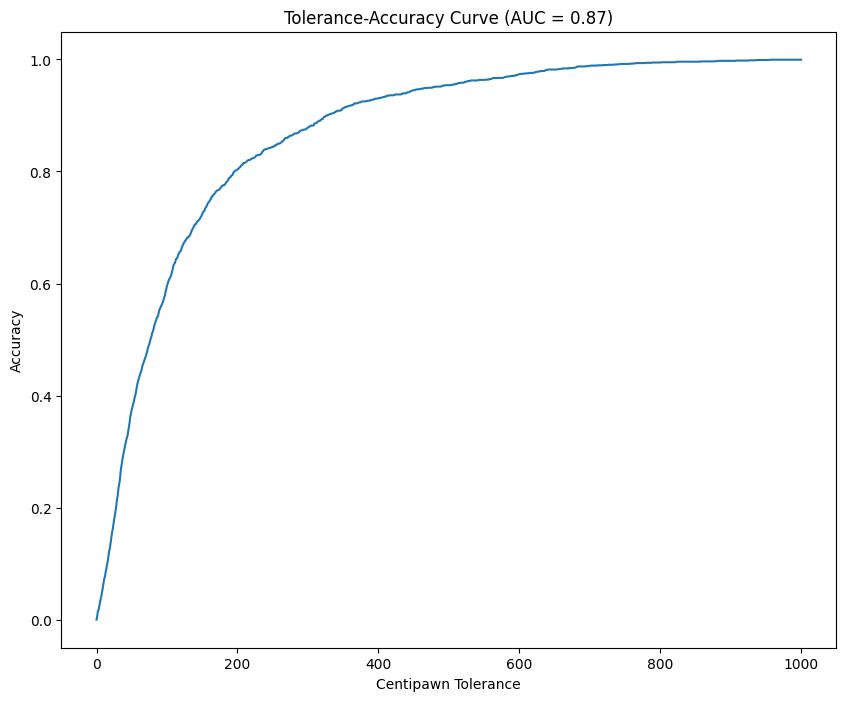

In [41]:
dm.train_test_split(list(PieceInfo.features | PawnStructure.features | KingSafety.features))
mm.fit()
mm.predict()
metm.report()
metm.plot_tol_acc()

As we add more features, the model performance stays roughly the same. We need to engineer more informative features to improve performance.

## Mobility

In chess, the mobility of the pieces is a crucial factor to consider, because if a piece has no mobility, it is useless to the player. We will consider the mobility of each piece in the game.

In [42]:
class PieceMobility:
    name = "Piece Mobility"
    features = {
        "Mobility_King_White", "Mobility_Queen_White", "Mobility_Rook_White",
        "Mobility_Bishop_White", "Mobility_Knight_White", "Mobility_Pawn_White",
        "Mobility_King_Black", "Mobility_Queen_Black", "Mobility_Rook_Black",
        "Mobility_Bishop_Black", "Mobility_Knight_Black", "Mobility_Pawn_Black"
    }

    @staticmethod
    def mobility(board, color, piece_type):
        moves_count = 0
        for square in board.pieces(piece_type, color):
            for move in board.legal_moves:
                if move.from_square == square:
                    moves_count += 1
        return moves_count

    @classmethod
    def transform(cls, df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()
        pieces = [chess.KING, chess.QUEEN, chess.ROOK, chess.BISHOP, chess.KNIGHT, chess.PAWN]
        colors = [(chess.WHITE, "White"), (chess.BLACK, "Black")]

        for color, cname in colors:
            for piece in pieces:
                pname = chess.piece_name(piece).capitalize()
                col_name = f"Mobility_{pname}_{cname}"
                out[col_name] = df["FEN"].apply(lambda fen: cls.mobility(chess.Board(fen), color, piece))
        
        return out
dm.apply_transformers([PieceMobility])

,FEN,White_Pieces,Black_Pieces,White_Piece_Value,Black_Piece_Value,White_Pawn,Black_Pawn,White_Knight,Black_Knight,White_Bishop,...,Mobility_Rook_White,Mobility_Bishop_White,Mobility_Knight_White,Mobility_Pawn_White,Mobility_King_Black,Mobility_Queen_Black,Mobility_Rook_Black,Mobility_Bishop_Black,Mobility_Knight_Black,Mobility_Pawn_Black
0,6r1/2R4p/2bp1p1K/4pP2/1pPkP1P1/1P1P1B2/8/8 b -...,9,8,1400,1300,6,5,0,0,1,...,0,0,0,0,4,0,11,8,0,1
1,1rbqr1k1/3n1pbp/pp1p2p1/2pP4/P3P1nN/1PN3PP/1BQ...,15,15,3800,3800,7,7,2,2,2,...,0,0,0,0,2,5,7,8,9,8
2,8/5pk1/7p/r5PP/5PK1/7R/8/8 b - - 2 105,5,4,800,700,3,2,0,0,0,...,0,0,0,0,4,0,13,0,0,3
3,r3r1k1/1b3pbp/1p2p1p1/p2pP3/2qP1P1B/P1N2R2/1P4...,13,13,3200,3200,7,7,1,0,1,...,0,0,0,0,2,15,10,8,0,7
4,8/5k2/4pp2/np6/4KPP1/1P6/8/2N5 b - - 3 34,5,5,600,600,3,3,1,1,0,...,0,0,0,0,6,0,0,0,4,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2kr4/4bp2/2pqb1p1/p2pN3/1p1P4/P2BP3/1PP3P1/2K1...,11,11,2600,2600,6,6,1,0,1,...,8,7,7,8,0,0,0,0,0,0
9996,3r1rk1/pbqnbppp/1p2pn2/2pp4/2P5/1P1PPNP1/PB1NQ...,16,16,3900,3900,8,8,2,2,2,...,8,8,7,9,0,0,0,0,0,0
9997,r2qbbk1/p5pn/1pp1r2p/2PpN3/1P1P2P1/2NQ1R1P/P4P...,14,13,3500,3400,7,6,2,1,1,...,0,0,0,0,1,9,7,7,2,7
9998,3r1rk1/pp3pb1/2n1b1pp/2pN4/4P2q/2NB4/PP3PPP/2R...,13,13,3400,3400,6,6,2,1,1,...,4,6,11,10,0,0,0,0,0,0


MSE: 41114.19973021874
Sign accuracy: 0.5935
White winning recall: 0.8839928057553957
Black winning recall: 0.3072289156626506
Draw recall: 0.0
Centipawn ±200 accuracy: 0.804


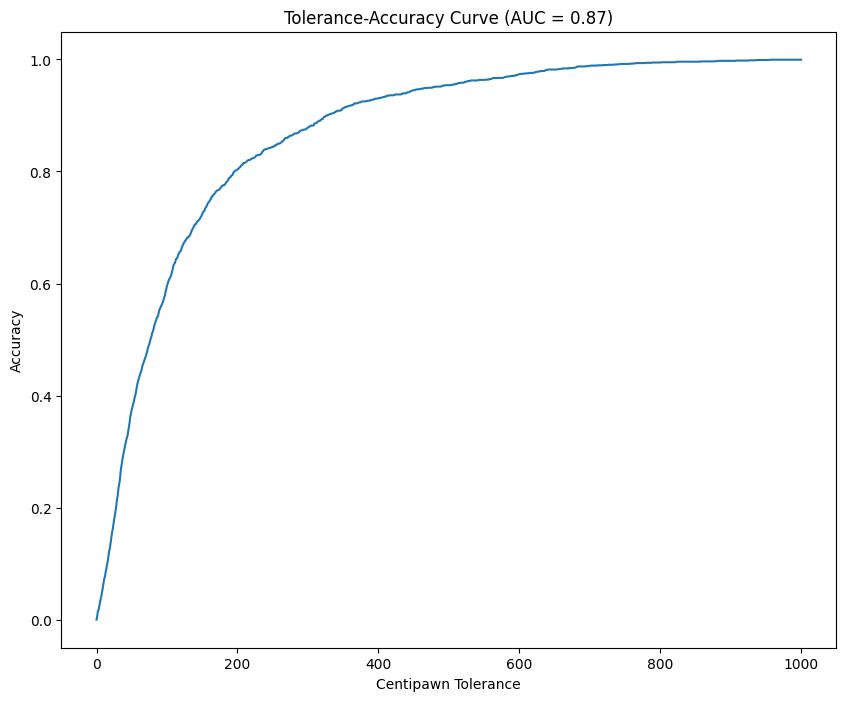

In [43]:
dm.train_test_split(list(PieceInfo.features | PawnStructure.features | KingSafety.features | PieceMobility.features))
mm.fit()
mm.predict()
metm.report()
metm.plot_tol_acc()

## Board control

The BoardControl class is important because it encodes essential positional factors that material alone cannot capture. Control of central squares, open and semi-open files, rook placement, protected advanced pawns, piece alignment, and total controlled squares all describe how active, coordinated, and dominant each side’s pieces are. These concepts directly influence long-term strategic advantages such as space, mobility, initiative, and attack potential.

In [44]:
class BoardControl:
    name = "Board Control"
    features = {
        "Central_Squares_Control_White",
        "Central_Squares_Control_Black",
        "Open_Columns_White",
        "Open_Columns_Black",
        "SemiOpen_Columns_White",
        "SemiOpen_Columns_Black",
        "Rook_on_Open_Column_White",
        "Rook_on_Open_Column_Black",
        "Protected_Advanced_Pawn_White",
        "Protected_Advanced_Pawn_Black",
        "Rook_Queen_Aligned_White",
        "Rook_Queen_Aligned_Black",
        "Rooks_Aligned_White",
        "Rooks_Aligned_Black",
        "Controlled_Squares_White",
        "Controlled_Squares_Black"
    }

    central_squares = [chess.D4, chess.D5, chess.E4, chess.E5]

    @staticmethod
    def central_control(board, color):
        """Nombre de caselles centrals controlades per un color"""
        control = 0
        for sq in BoardControl.central_squares:
            if board.is_attacked_by(color, sq):
                control += 1
        return control

    @staticmethod
    def open_columns(board, color):
        """Compta columnes completament obertes i semiobertes"""
        open_cols = 0
        semi_open_cols = 0
        for f in range(8):
            pawns_w = any(board.piece_at(chess.square(f, r)) == chess.Piece(chess.PAWN, chess.WHITE) for r in range(8))
            pawns_b = any(board.piece_at(chess.square(f, r)) == chess.Piece(chess.PAWN, chess.BLACK) for r in range(8))
            if not pawns_w and not pawns_b:
                open_cols += 1
            elif not (color == chess.WHITE and pawns_w) and not (color == chess.BLACK and pawns_b):
                semi_open_cols += 1
        return open_cols, semi_open_cols

    @staticmethod
    def rook_on_open_column(board, color):
        """Comprova si hi ha torre en columna oberta"""
        open_cols, _ = BoardControl.open_columns(board, color)
        rooks = board.pieces(chess.ROOK, color)
        for r in rooks:
            f = chess.square_file(r)
            pawns_w = any(board.piece_at(chess.square(f, rr)) == chess.Piece(chess.PAWN, chess.WHITE) for rr in range(8))
            pawns_b = any(board.piece_at(chess.square(f, rr)) == chess.Piece(chess.PAWN, chess.BLACK) for rr in range(8))
            if not pawns_w and not pawns_b:
                return 1
        return 0

    @staticmethod
    def protected_advanced_pawn(board, color):
        """Peó avançat protegit (en fila 4,5,6)"""
        rank_range = range(3, 6) if color == chess.WHITE else range(2, 5)
        for r in rank_range:
            for f in range(8):
                sq = chess.square(f, r)
                piece = board.piece_at(sq)
                if piece and piece.piece_type == chess.PAWN and piece.color == color:
                    # comprova si alguna peça protegeix el peó
                    if any(board.is_attacked_by(color, p) and board.piece_at(p).piece_type != chess.PAWN for p in board.pieces(chess.QUEEN, color) | board.pieces(chess.ROOK, color) | board.pieces(chess.KNIGHT, color) | board.pieces(chess.BISHOP, color)):
                        return 1
        return 0

    @staticmethod
    def aligned_pieces(board, color, major_only=True):
        """Torre + dama alineades o torres alineades"""
        rooks = list(board.pieces(chess.ROOK, color))
        queens = list(board.pieces(chess.QUEEN, color))
        aligned_rook_queen = 0
        aligned_rooks = 0

        for r in rooks:
            rf = chess.square_file(r)
            rr = chess.square_rank(r)
            # comprova alineació amb reina
            for q in queens:
                qf = chess.square_file(q)
                qr = chess.square_rank(q)
                if rf == qf or rr == qr:
                    aligned_rook_queen = 1
            # comprova alineació amb altra torre
            for r2 in rooks:
                if r != r2:
                    r2f = chess.square_file(r2)
                    r2r = chess.square_rank(r2)
                    if rf == r2f or rr == r2r:
                        aligned_rooks = 1
        return aligned_rook_queen, aligned_rooks

    @staticmethod
    def controlled_squares(board, color):
        """Nombre total de caselles controlades per totes les peces"""
        controlled = set()
        for sq in chess.SQUARES:
            if board.is_attacked_by(color, sq):
                controlled.add(sq)
        return len(controlled)

    @classmethod
    def transform(cls, df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()
        colors = [(chess.WHITE, "White"), (chess.BLACK, "Black")]

        for color, cname in colors:
            out[f"Central_Squares_Control_{cname}"] = df["FEN"].apply(lambda fen: cls.central_control(chess.Board(fen), color))

            out[f"Open_Columns_{cname}"], out[f"SemiOpen_Columns_{cname}"] = zip(*df["FEN"].apply(lambda fen: cls.open_columns(chess.Board(fen), color)))

            out[f"Rook_on_Open_Column_{cname}"] = df["FEN"].apply(lambda fen: cls.rook_on_open_column(chess.Board(fen), color))

            out[f"Protected_Advanced_Pawn_{cname}"] = df["FEN"].apply(lambda fen: cls.protected_advanced_pawn(chess.Board(fen), color))

            aligned_queen, aligned_rooks = zip(*df["FEN"].apply(lambda fen: cls.aligned_pieces(chess.Board(fen), color)))
            out[f"Rook_Queen_Aligned_{cname}"] = aligned_queen
            out[f"Rooks_Aligned_{cname}"] = aligned_rooks

            out[f"Controlled_Squares_{cname}"] = df["FEN"].apply(lambda fen: cls.controlled_squares(chess.Board(fen), color))

        return out
dm.apply_transformers([BoardControl])

,FEN,White_Pieces,Black_Pieces,White_Piece_Value,Black_Piece_Value,White_Pawn,Black_Pawn,White_Knight,Black_Knight,White_Bishop,...,Rooks_Aligned_White,Controlled_Squares_White,Central_Squares_Control_Black,Open_Columns_Black,SemiOpen_Columns_Black,Rook_on_Open_Column_Black,Protected_Advanced_Pawn_Black,Rook_Queen_Aligned_Black,Rooks_Aligned_Black,Controlled_Squares_Black
0,6r1/2R4p/2bp1p1K/4pP2/1pPkP1P1/1P1P1B2/8/8 b -...,9,8,1400,1300,6,5,0,0,1,...,0,24,4,1,2,0,0,0,0,26
1,1rbqr1k1/3n1pbp/pp1p2p1/2pP4/P3P1nN/1PN3PP/1BQ...,15,15,3800,3800,7,7,2,2,2,...,1,35,3,0,1,0,1,1,1,36
2,8/5pk1/7p/r5PP/5PK1/7R/8/8 b - - 2 105,5,4,800,700,3,2,0,0,0,...,0,19,2,5,1,1,0,0,0,22
3,r3r1k1/1b3pbp/1p2p1p1/p2pP3/2qP1P1B/P1N2R2/1P4...,13,13,3200,3200,7,7,1,0,1,...,0,36,4,1,0,0,1,0,1,38
4,8/5k2/4pp2/np6/4KPP1/1P6/8/2N5 b - - 3 34,5,5,600,600,3,3,1,1,0,...,0,15,2,4,1,0,0,0,0,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2kr4/4bp2/2pqb1p1/p2pN3/1p1P4/P2BP3/1PP3P1/2K1...,11,11,2600,2600,6,6,1,0,1,...,0,37,3,1,1,0,1,1,0,32
9996,3r1rk1/pbqnbppp/1p2pn2/2pp4/2P5/1P1PPNP1/PB1NQ...,16,16,3900,3900,8,8,2,2,2,...,1,32,4,0,0,0,1,0,1,34
9997,r2qbbk1/p5pn/1pp1r2p/2PpN3/1P1P2P1/2NQ1R1P/P4P...,14,13,3500,3400,7,6,2,1,1,...,0,44,3,1,1,1,1,1,0,30
9998,3r1rk1/pp3pb1/2n1b1pp/2pN4/4P2q/2NB4/PP3PPP/2R...,13,13,3400,3400,6,6,2,1,1,...,1,38,4,1,1,1,1,0,1,38


MSE: 41114.19973021874
Sign accuracy: 0.5935
White winning recall: 0.8839928057553957
Black winning recall: 0.3072289156626506
Draw recall: 0.0
Centipawn ±200 accuracy: 0.804


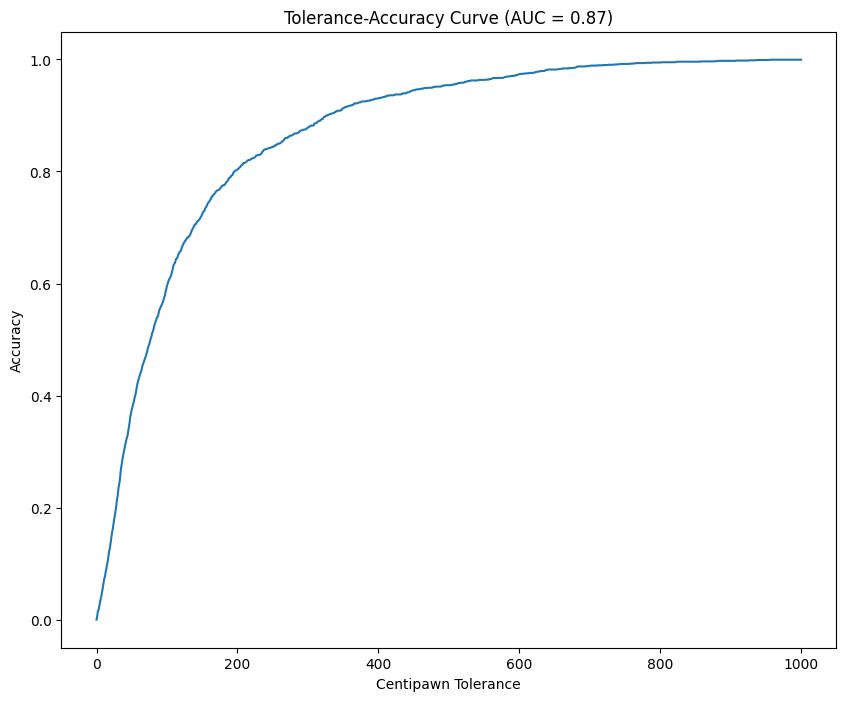

In [45]:
dm.train_test_split(list(PieceInfo.features | PawnStructure.features | KingSafety.features | PieceMobility.features | BoardControl.features))
mm.fit()
mm.predict()
metm.report()
metm.plot_tol_acc()

## Relations

In [46]:
dm.train_test_split(list(PieceInfo.features | PawnStructure.features | KingSafety.features | PieceMobility.features | BoardControl.features | Relations.features))
mm.fit()
mm.predict()
metm.report()
metm.plot_tol_acc()

NameError: name 'Relations' is not defined

## Miscellaneous

In this section, we will address the remaining features that are not grouped semantically. These are the player to move, the number of moves, and the number of halfmoves since the last capture or pawn advance (halfmove clock), denoted as $B$, $E$, and $F$, respectively.

In [ ]:
class MiscFeatures:
    name = "Miscellaneous Features"
    features = {"Player_to_Move", "Number_of_Moves", "Halfmove_Clock"}

    @staticmethod
    def player_to_move(fen):
        """B: Player to move (1 for White, 0 for Black)"""
        board = chess.Board(fen)
        return 1 if board.turn == chess.WHITE else 0

    @staticmethod
    def number_of_moves(fen):
        """E: Fullmove number from FEN"""
        board = chess.Board(fen)
        return board.fullmove_number

    @staticmethod
    def halfmove_clock(fen):
        """F: Halfmove clock from FEN"""
        board = chess.Board(fen)
        return board.halfmove_clock

    @classmethod
    def transform(cls, df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()
        out["Player_to_Move"] = df["FEN"].apply(cls.player_to_move)
        out["Number_of_Moves"] = df["FEN"].apply(cls.number_of_moves)
        out["Halfmove_Clock"] = df["FEN"].apply(cls.halfmove_clock)
        return out
dm.apply_transformers([MiscFeatures])

In [ ]:
dm.train_test_split(list(PieceInfo.features | PawnStructure.features | KingSafety.features | PieceMobility.features | BoardControl.features | Relations.features | MiscFeatures.features))
mm.fit()
mm.predict()
metm.report()
metm.plot_tol_acc()

---

# FULL

In [ ]:
dm = DataManager(
    filepath=DATASET_FILE,
    read_size=2_000_000,
    sample_size=500_000,
    transformers=[PieceInfo, PawnStructure, KingSafety],
)

KeyboardInterrupt: 

In [ ]:
mm_gb = ModelManager(GradientBoostingRegressor(), dm)

In [ ]:
metm = MetricsManager(mm_gb)
metm.report()
metm.plot_tol_acc()
metm.plot_scatter()

InvalidParameterError: The 'y_pred' parameter of mean_squared_error must be an array-like. Got None instead.

In [ ]:
mm_lr = ModelManager(LinearRegression(), dm)

In [ ]:
mm_lr.predict()

metm = MetricsManager(mm_lr)
metm.report()
metm.plot_tol_acc()
metm.plot_scatter()

---

In [ ]:
# xat
PIECE_VALUES = {
    chess.PAWN: 1.0,
    chess.KNIGHT: 3.0,
    chess.BISHOP: 3.0,
    chess.ROOK: 5.0,
    chess.QUEEN: 9.0,
    chess.KING: 0.0
}

CENTRAL_SQUARES = {chess.E4, chess.D4, chess.E5, chess.D5}

def is_passed_pawn(board, square, color):
    file = chess.square_file(square)
    rank = chess.square_rank(square)
    if color == chess.WHITE:
        # any black pawn on same or adjacent file ahead (higher ranks)?
        for r in range(rank + 1, 8):
            for f in (file - 1, file, file + 1):
                if 0 <= f < 8:
                    sq = chess.square(f, r)
                    piece = board.piece_type_at(sq)
                    if piece == chess.PAWN and not board.color_at(sq):
                        return False
        return True
    else:
        # black pawn: look for white pawns ahead (lower ranks)
        for r in range(rank - 1, -1, -1):
            for f in (file - 1, file, file + 1):
                if 0 <= f < 8:
                    sq = chess.square(f, r)
                    piece = board.piece_type_at(sq)
                    if piece == chess.PAWN and board.color_at(sq):
                        return False
        return True

def pawn_stats(board, color):
    pawns = [sq for sq, piece in board.piece_map().items() if piece.piece_type == chess.PAWN and piece.color == color]
    files = {}
    doubled = 0
    isolated = 0
    passed = 0
    for sq in pawns:
        f = chess.square_file(sq)
        files.setdefault(f, 0)
        files[f] += 1
    doubled = sum(count - 1 for count in files.values() if count > 1)
    # isolated: file has pawns ==1 and no pawns on adjacent files
    for f, count in files.items():
        if count == 1 and files.get(f - 1, 0) == 0 and files.get(f + 1, 0) == 0:
            isolated += 1
    for sq in pawns:
        if is_passed_pawn(board, sq, color):
            passed += 1
    pawn_islands = 0
    sorted_files = sorted(files.keys())
    if sorted_files:
        prev = sorted_files[0] - 2
        for f in sorted_files:
            if f != prev + 1:
                pawn_islands += 1
            prev = f
    return {"doubled": doubled, "isolated": isolated, "passed": passed, "islands": pawn_islands}

def extract_features_from_fen(fen: str) -> dict:
    b = chess.Board(fen)
    features = {}
    # counts and material
    for color, prefix in ((chess.WHITE, "W_"), (chess.BLACK, "B_")):
        mat = 0.0
        for ptype in (chess.PAWN, chess.KNIGHT, chess.BISHOP, chess.ROOK, chess.QUEEN, chess.KING):
            cnt = len([1 for sq, pc in b.piece_map().items() if pc.piece_type == ptype and pc.color == color])
            features[f"{prefix}count_{ptype}"] = cnt
            mat += cnt * PIECE_VALUES[ptype]
        features[f"{prefix}material"] = mat
        # bishop pair
        features[f"{prefix}bishop_pair"] = int(features[f"{prefix}count_{chess.BISHOP}"] >= 2)
    # material diff and total
    features["mat_diff"] = features["W_material"] - features["B_material"]
    features["mat_total"] = features["W_material"] + features["B_material"]

    # mobility: legal moves for each side
    b_white = b.copy()
    b_white.turn = True
    features["mobility_white"] = len(list(b_white.legal_moves))
    b_black = b.copy()
    b_black.turn = False
    features["mobility_black"] = len(list(b_black.legal_moves))
    # mobility for side to move
    features["mobility_to_move"] = len(list(b.legal_moves))

    # king safety: attackers on king and in king zone
    wk_sq = b.king(chess.WHITE)
    bk_sq = b.king(chess.BLACK)
    features["W_king_attackers"] = 0 if wk_sq is None else len(b.attackers(chess.BLACK, wk_sq))
    features["B_king_attackers"] = 0 if bk_sq is None else len(b.attackers(chess.WHITE, bk_sq))
    # king zone attackers
    def king_zone_attackers(board, king_sq, attacker_color):
        if king_sq is None:
            return 0
        zone = [king_sq] + [n for n in chess.SQUARES if chess.square_distance(king_sq, n) == 1]
        return sum(len(board.attackers(attacker_color, sq)) for sq in zone)
    features["W_king_zone_attackers"] = king_zone_attackers(b, wk_sq, chess.BLACK)
    features["B_king_zone_attackers"] = king_zone_attackers(b, bk_sq, chess.WHITE)

    # pawn structure features
    pw = pawn_stats(b, chess.WHITE)
    pb = pawn_stats(b, chess.BLACK)
    for k, v in pw.items():
        features[f"W_pawn_{k}"] = v
    for k, v in pb.items():
        features[f"B_pawn_{k}"] = v

    # center control: attacks on central squares
    features["center_control_white"] = sum(1 for sq in CENTRAL_SQUARES if b.is_attacked_by(chess.WHITE, sq))
    features["center_control_black"] = sum(1 for sq in CENTRAL_SQUARES if b.is_attacked_by(chess.BLACK, sq))

    # central piece presence
    features["W_central_pieces"] = sum(1 for sq, pc in b.piece_map().items() if pc.color == chess.WHITE and sq in CENTRAL_SQUARES)
    features["B_central_pieces"] = sum(1 for sq, pc in b.piece_map().items() if pc.color == chess.BLACK and sq in CENTRAL_SQUARES)

    # castling rights and en-passant
    features["W_can_castle_kingside"] = int(b.has_kingside_castling_rights(chess.WHITE))
    features["W_can_castle_queenside"] = int(b.has_queenside_castling_rights(chess.WHITE))
    features["B_can_castle_kingside"] = int(b.has_kingside_castling_rights(chess.BLACK))
    features["B_can_castle_queenside"] = int(b.has_queenside_castling_rights(chess.BLACK))
    features["has_ep"] = int(b.ep_square is not None)
    features["in_check"] = int(b.is_check())

    # move counters / phase
    features["halfmove_clock"] = b.halfmove_clock
    features["fullmove_number"] = b.fullmove_number
    initial_total = sum(v * cnt for v, cnt in [
        (PIECE_VALUES[chess.PAWN], 16),
        (PIECE_VALUES[chess.KNIGHT], 4),
        (PIECE_VALUES[chess.BISHOP], 4),
        (PIECE_VALUES[chess.ROOK], 4),
        (PIECE_VALUES[chess.QUEEN], 2),
    ])
    features["phase"] = (features["mat_total"] / initial_total) if initial_total > 0 else 0.0

    # side to move
    features["side_to_move_white"] = int(b.turn)

    return features

rows = [extract_features_from_fen(fen) for fen in dm.df[FEN]]
X = pd.DataFrame(rows)
y = dm.df[EVAL]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

dm2 = DataManager(DATASET_FILE, read_size=1, sample_size=1)
dm2.X_train, dm2.X_test, dm2.y_train, dm2.y_test = X_train, X_test, y_train, y_test
mm2 = ModelManager(GradientBoostingRegressor(), dm2)

In [ ]:
mm2.predict()

metm2 = MetricsManager(mm2)
metm2.report()
metm2.plot_tol_acc()
metm.plot_scatter()

sampling from 15_000_000:

- Mean Squared Error: 47108.02274584996
- Sign accuracy: 0.67685
- Positive sign recall: 0.8400834677036897
- Negative sign recall: 0.6334596643205198
- Centipawn ±200 accuracy: 0.76635

sampling from 200_00:

- Mean Squared Error: 29028.021170256125
- Sign accuracy: 0.66445
- Positive sign recall: 0.8580901856763926
- Negative sign recall: 0.5744510338195223
- Centipawn ±200 accuracy: 0.863